In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import re
import matplotlib.patches as Patch


In [2]:
SMALL_SIZE = 11
MEDIUM_SIZE = 12.5
BIGGER_SIZE = 15

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

plt.rcParams["text.usetex"] = False
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"

## Multi-Start mega figure

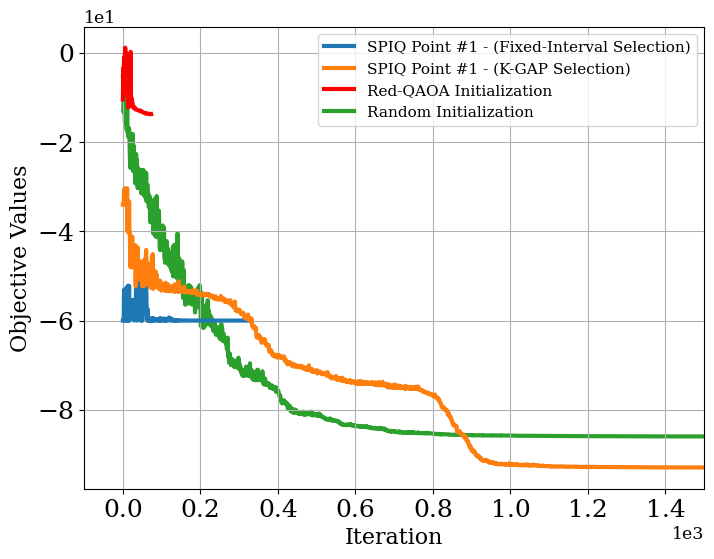

In [3]:
#Maxcut Gradient Norm - Good example

# plot_cafqa_analysis('../np_data/CAFQA_Analysis/Teague_data/14_qbs/Long_COBYLA_best_spaced_5_point_analysis_1.npy',
#                     title='Analysis of ma-QAOA with different starting points \n 14 Feature Cancer Genomics Data')


cafqa_diff_points_data = np.load('../np_data/Final_Data_Collection/Multi-Start/Gradient_Norm/Maxcut/12_qbs/result_3_clustering_k_means.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'CAFQA_Spaced_{i}' for i in range(1)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(8, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'SPIQ Point #{i+1} - (Fixed-Interval Selection)',linewidth=3)


# Extract obj_values for CAFQA_Clustering points
clustering_tasks = [f'CAFQA_Clustering_{2}' for i in range(1)]
clustering_obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in clustering_tasks}

# Plot all obj_values for CAFQA_Clustering points on the same plot
for i, (task, values) in enumerate(clustering_obj_values.items()):
    plt.plot(values, label=f'SPIQ Point #{i+1} - (K-GAP Selection)', linewidth=3)

red_qaoa_full_run_data = np.load('../np_data/Final_Data_Collection/Multi-Start/Red_QAOA_full_runs/Maxcut/12_qbs/result_seed_3.npy', allow_pickle=True).item()
red_qaoa_obj_values = red_qaoa_full_run_data['obj_values']
plt.plot(red_qaoa_obj_values, label='Red-QAOA Initialization', linewidth=3, color='red')
# plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA', zorder=7,linewidth=3)
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Initialization', linewidth=3, color="tab:green", zorder=1)

# best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']

# Add labels, title, legend, and grid
plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Iteration', fontsize=16)
plt.ylabel('Objective Values',fontsize=16)
# plt.axhline(y=best_cafqa_energy, color='r', linestyle='--', label='Best CAFQA Initialization')
# plt.scatter(0, obj_values['CAFQA_Spaced_0'][0], color="#001e8d", s=200, zorder=5, marker='x', linewidths=4, label='Best CAFQA Point')
# plt.title('QAOA for PCBO on \n 14 Feature Cancer Genomics Data')
# plt.axhline(y=-26014.18, color='b', linestyle='--', label='Ground State Energy')

plt.xlim(-100,1500)
plt.legend()
plt.grid()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
fig1 = plt.gcf()     # get current figure
# plt.savefig('../plots/teague_14_feature_cancer_genomics.pdf', dpi=500, bbox_inches='tight')
plt.show()

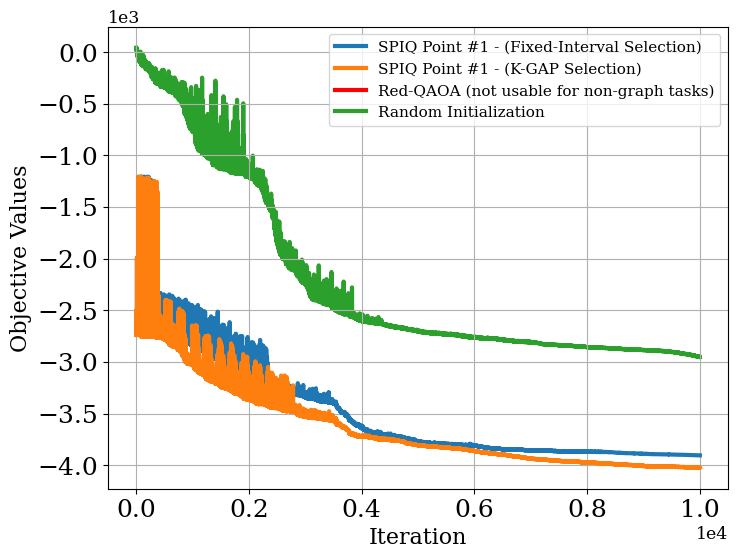

In [4]:
# K-means Gradient Norm - Good 
# plot_cafqa_analysis('../np_data/CAFQA_Analysis/Teague_data/14_qbs/Long_COBYLA_best_spaced_5_point_analysis_1.npy',
#                     title='Analysis of ma-QAOA with different starting points \n 14 Feature Cancer Genomics Data')


cafqa_diff_points_data = np.load('../np_data/Final_Data_Collection/Multi-Start/Gradient_Norm/Knapsack/9_qbs/result_3_clustering_k_means_1.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'CAFQA_Spaced_{i}' for i in range(1)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(8, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'SPIQ Point #{i+1} - (Fixed-Interval Selection)',linewidth=3)

# Extract obj_values for CAFQA_Clustering points
clustering_tasks = [f'CAFQA_Clustering_{i}' for i in range(1)]
clustering_obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in clustering_tasks}

# Plot all obj_values for CAFQA_Clustering points on the same plot
for i, (task, values) in enumerate(clustering_obj_values.items()):
    plt.plot(values, label=f'SPIQ Point #{i+1} - (K-GAP Selection)', linewidth=3)

# plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA', zorder=7,linewidth=3)

#Fake Red-QAOA data for label 
ax = plt.gca()
ax.plot([], [], color='red', linewidth=3,
        label='Red-QAOA (not usable for non-graph tasks)')

plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Initialization', linewidth=3, color="tab:green", zorder=1)

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']

# Add labels, title, legend, and grid
plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Iteration', fontsize=16)
plt.ylabel('Objective Values',fontsize=16)
# plt.axhline(y=best_cafqa_energy, color='r', linestyle='--', label='Best CAFQA Initialization')
# plt.scatter(0, obj_values['CAFQA_Spaced_0'][0], color="#001e8d", s=200, zorder=5, marker='x', linewidths=4, label='Best CAFQA Point')
# plt.title('QAOA for PCBO on \n 14 Feature Cancer Genomics Data')
# plt.xlim(-200,5000)
plt.legend()
plt.grid()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
fig2 = plt.gcf()     # get current figure
# plt.savefig('../plots/teague_14_feature_cancer_genomics.pdf', dpi=500, bbox_inches='tight')
plt.show()

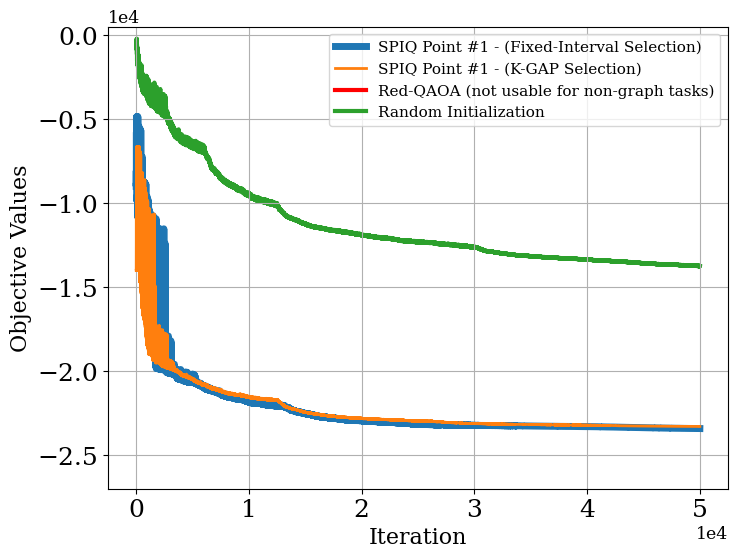

In [5]:
# K-means Gradient Norm 
# plot_cafqa_analysis('../np_data/CAFQA_Analysis/Teague_data/14_qbs/Long_COBYLA_best_spaced_5_point_analysis_1.npy',
#                     title='Analysis of ma-QAOA with different starting points \n 14 Feature Cancer Genomics Data')


cafqa_diff_points_data = np.load('../np_data/Final_Data_Collection/Multi-Start/Gradient_Norm/Teague/12_qbs/result_3_clustering_k_means.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'CAFQA_Spaced_{1}' for i in range(1)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(8, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'SPIQ Point #{i+1} - (Fixed-Interval Selection)',linewidth=5)

# Extract obj_values for CAFQA_Clustering points
clustering_tasks = [f'CAFQA_Clustering_{i}' for i in range(1)]
clustering_obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in clustering_tasks}

# Plot all obj_values for CAFQA_Clustering points on the same plot
for i, (task, values) in enumerate(clustering_obj_values.items()):
    plt.plot(values, label=f'SPIQ Point #{i+1} - (K-GAP Selection)', linewidth=2)

# plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA', zorder=7,linewidth=3)

#Fake Red-QAOA data for label 
ax = plt.gca()
ax.plot([], [], color='red', linewidth=3,
        label='Red-QAOA (not usable for non-graph tasks)')

plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Initialization', linewidth=3, color="tab:green", zorder=1)

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']

# Add labels, title, legend, and grid
plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Iteration', fontsize=16)
plt.ylabel('Objective Values',fontsize=16)
# plt.axhline(y=best_cafqa_energy, color='r', linestyle='--', label='Best CAFQA Initialization')
# plt.scatter(0, obj_values['CAFQA_Spaced_0'][0], color="#001e8d", s=200, zorder=5, marker='x', linewidths=4, label='Best CAFQA Point')
# plt.title('QAOA for PCBO on \n 14 Feature Cancer Genomics Data')
plt.ylim(-27000,500)
plt.legend()
plt.grid()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
fig3 = plt.gcf()     # get current figure
# plt.savefig('../plots/teague_14_feature_cancer_genomics.pdf', dpi=500, bbox_inches='tight')
plt.show()

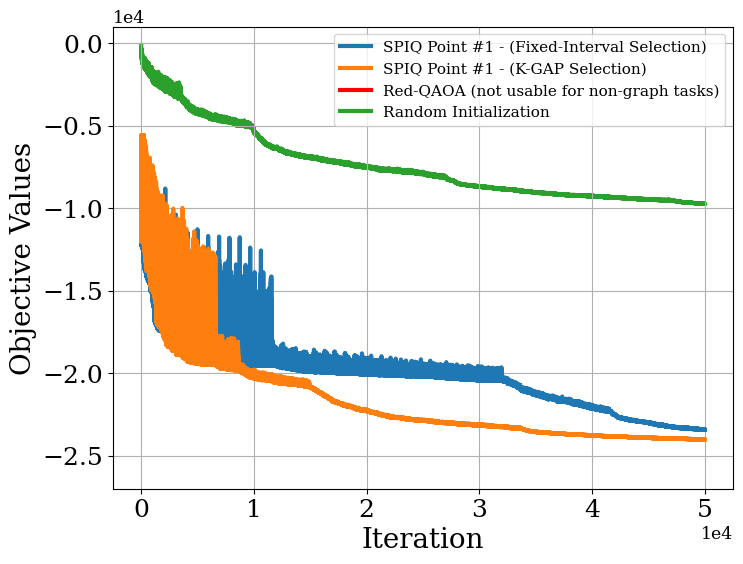

In [6]:
#Fig 4 

# K-means Gradient Norm - Good example
# plot_cafqa_analysis('../np_data/CAFQA_Analysis/Teague_data/14_qbs/Long_COBYLA_best_spaced_5_point_analysis_1.npy',
#                     title='Analysis of ma-QAOA with different starting points \n 14 Feature Cancer Genomics Data')


cafqa_diff_points_data = np.load('../np_data/Final_Data_Collection/Multi-Start/Gradient_Norm/Teague/14_qbs/result_41_clustering_k_means.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'CAFQA_Spaced_{i}' for i in range(1)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(8, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'SPIQ Point #{i+1} - (Fixed-Interval Selection)',linewidth=3)

# Extract obj_values for CAFQA_Clustering points
clustering_tasks = [f'CAFQA_Clustering_{i}' for i in range(1)]
clustering_obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in clustering_tasks}

# Plot all obj_values for CAFQA_Clustering points on the same plot
for i, (task, values) in enumerate(clustering_obj_values.items()):
    plt.plot(values, label=f'SPIQ Point #{i+1} - (K-GAP Selection)', linewidth=3)

# plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA', zorder=7,linewidth=3)

#Fake Red-QAOA data for label 
ax = plt.gca()
ax.plot([], [], color='red', linewidth=3,
        label='Red-QAOA (not usable for non-graph tasks)')

plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Initialization', linewidth=3, color="tab:green", zorder=1)

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']

# Add labels, title, legend, and grid
plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Iteration', fontsize=20)
plt.ylabel('Objective Values',fontsize=20)
# plt.axhline(y=best_cafqa_energy, color='r', linestyle='--', label='Best CAFQA Initialization')
# plt.scatter(0, obj_values['CAFQA_Spaced_0'][0], color="#001e8d", s=200, zorder=5, marker='x', linewidths=4, label='Best CAFQA Point')
# plt.title('QAOA for PCBO on \n 14 Feature Cancer Genomics Data')
# plt.axhline(y=-26014.18, color='b', linestyle='--', label='Ground State Energy')
# Add a dummy plot just for the legend


plt.ylim(-27000,1000)
plt.legend()
plt.grid()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
# plt.savefig('../plots/teague_14_feature_cancer_genomics.pdf', dpi=500, bbox_inches='tight')

# # --- Create custom legend item ---
# from matplotlib.lines import Line2D
# custom_handle = Line2D([], [], color='red', label='Custom Label',linewidth=2)

# # --- Extract existing legend items ---
# ax = plt.gca()
# handles, labels = ax.get_legend_handles_labels()

# # Insert custom item between item 2 and 3
# insert_pos = 2
# handles = handles[:insert_pos] + [custom_handle] + handles[insert_pos:]
# labels  = labels[:insert_pos]  + ['Red-QAOA Initialization (inapplicable beyond graph-based tasks)'] + labels[insert_pos:]

# # Rebuild legend
# legend = ax.legend(handles, labels, loc='upper right')
# ax._legend = legend        # <--- this makes it persistent

fig4 = plt.gcf()     # get current figure
plt.show()

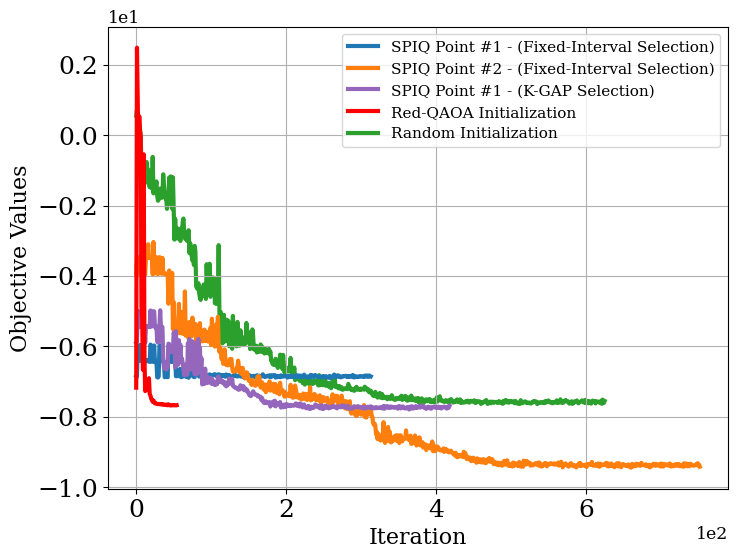

In [7]:

# K-means Gradient Norm #Noisy - Good

# cafqa_diff_points_data['Task_results']['Red_qaoa_task']


cafqa_diff_points_data = np.load('../np_data/Final_Data_Collection/Multi-Start/Gradient_Norm/Maxcut/noisy/10_qbs/result_3_clustering_k_means.npy', allow_pickle=True).item()

# Extract obj_values for task_0 and task_2
tasks = ['CAFQA_Spaced_0', 'CAFQA_Spaced_2']
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot obj_values for task_0 and task_2
plt.figure(figsize=(8, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'SPIQ Point #{i+1} - (Fixed-Interval Selection)', linewidth=3)

# Extract obj_values for CAFQA_Clustering points
clustering_tasks = [f'CAFQA_Clustering_{0}' for i in range(1)]
clustering_obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in clustering_tasks}

# Plot all obj_values for CAFQA_Clustering points on the same plot
for i, (task, values) in enumerate(clustering_obj_values.items()):
    plt.plot(values, label=f'SPIQ Point #{i+1} - (K-GAP Selection)', linewidth=3,color="tab:purple")

plt.plot(cafqa_diff_points_data['Task_results']['Red_qaoa_task']['obj_values'], label='Red-QAOA Initialization', linewidth=3, color='red')
# plt.plot(cafqa_diff_points_data['Task_results']['Vanilla_task']['obj_values'], label='Random Init. Vanilla QAOA', zorder=7,linewidth=3)
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Initialization', linewidth=3, color="tab:green", zorder=1)

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']

# Add labels, title, legend, and grid
plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Iteration', fontsize=16)
plt.ylabel('Objective Values',fontsize=16)
# plt.axhline(y=best_cafqa_energy, color='r', linestyle='--', label='Best CAFQA Initialization')
# plt.scatter(0, obj_values['CAFQA_Spaced_0'][0], color="#001e8d", s=200, zorder=5, marker='x', linewidths=4, label='Best CAFQA Point')
# plt.title('QAOA for PCBO on \n 14 Feature Cancer Genomics Data')

plt.legend()
plt.grid()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))
fig5 = plt.gcf()     # get current figure

# plt.savefig('../plots/teague_14_feature_cancer_genomics.pdf', dpi=500, bbox_inches='tight')
plt.show()



#NOTE: dont worry about result because cafqa can find better with more gens. also this is unweighted problem.

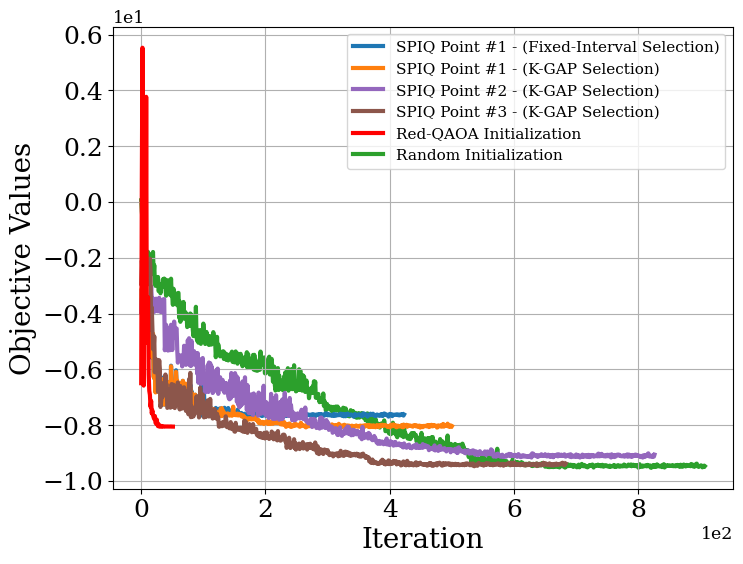

In [8]:
# fig 6 outlier noisy


# K-means Gradient Norm #Noisy Final day 

cafqa_diff_points_data = np.load('../np_data/Final_Data_Collection/Multi-Start/Gradient_Norm/Maxcut/noisy/12_qbs/result_3_clustering_k_means.npy', allow_pickle=True).item()

# Extract obj_values from task_0 to task_4
tasks = [f'CAFQA_Spaced_{i}' for i in range(1)]
obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in tasks}

# Plot all obj_values on the same plot
plt.figure(figsize=(8, 6))
for i, (task, values) in enumerate(obj_values.items()):
    plt.plot(values, label=f'SPIQ Point #{i+1} - (Fixed-Interval Selection)',linewidth=3)

# Extract obj_values for CAFQA_Clustering points
clustering_tasks = [f'CAFQA_Clustering_{i}' for i in range(3)]
clustering_obj_values = {task: cafqa_diff_points_data['Task_results'][task]['obj_values'] for task in clustering_tasks}

# Plot all obj_values for CAFQA_Clustering points on the same plot
custom_colors = ['tab:orange', 'tab:purple', 'tab:brown']  # Define custom colors
for i, (task, values) in enumerate(clustering_obj_values.items()):
    plt.plot(values, label=f'SPIQ Point #{i+1} - (K-GAP Selection)', linewidth=3, color=custom_colors[i % len(custom_colors)])

plt.plot(cafqa_diff_points_data['Task_results']['Red_qaoa_task']['obj_values'], label='Red-QAOA Initialization', linewidth=3,color="red")
plt.plot(cafqa_diff_points_data['Task_results']['Random_MA-QAOA']['obj_values'], label='Random Initialization', linewidth=3, color="tab:green", zorder=1)

best_cafqa_energy = cafqa_diff_points_data['CAFQA_initialization_energy']

# Add labels, title, legend, and grid
plt.tick_params(axis='both', which='major', labelsize=18)
plt.xlabel('Iteration', fontsize=20)
plt.ylabel('Objective Values',fontsize=20)
# plt.axhline(y=best_cafqa_energy, color='r', linestyle='--', label='Best CAFQA Initialization')
# plt.scatter(0, obj_values['CAFQA_Spaced_0'][0], color="#001e8d", s=200, zorder=5, marker='x', linewidths=4, label='Best CAFQA Point')
# plt.title('QAOA for PCBO on \n 14 Feature Cancer Genomics Data')

plt.legend()
plt.grid()
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

fig6 = plt.gcf() 

plt.show()

#NOTE: dont worry about result because cafqa can find better with more gens. also this is unweighted problem.


## Final Figure

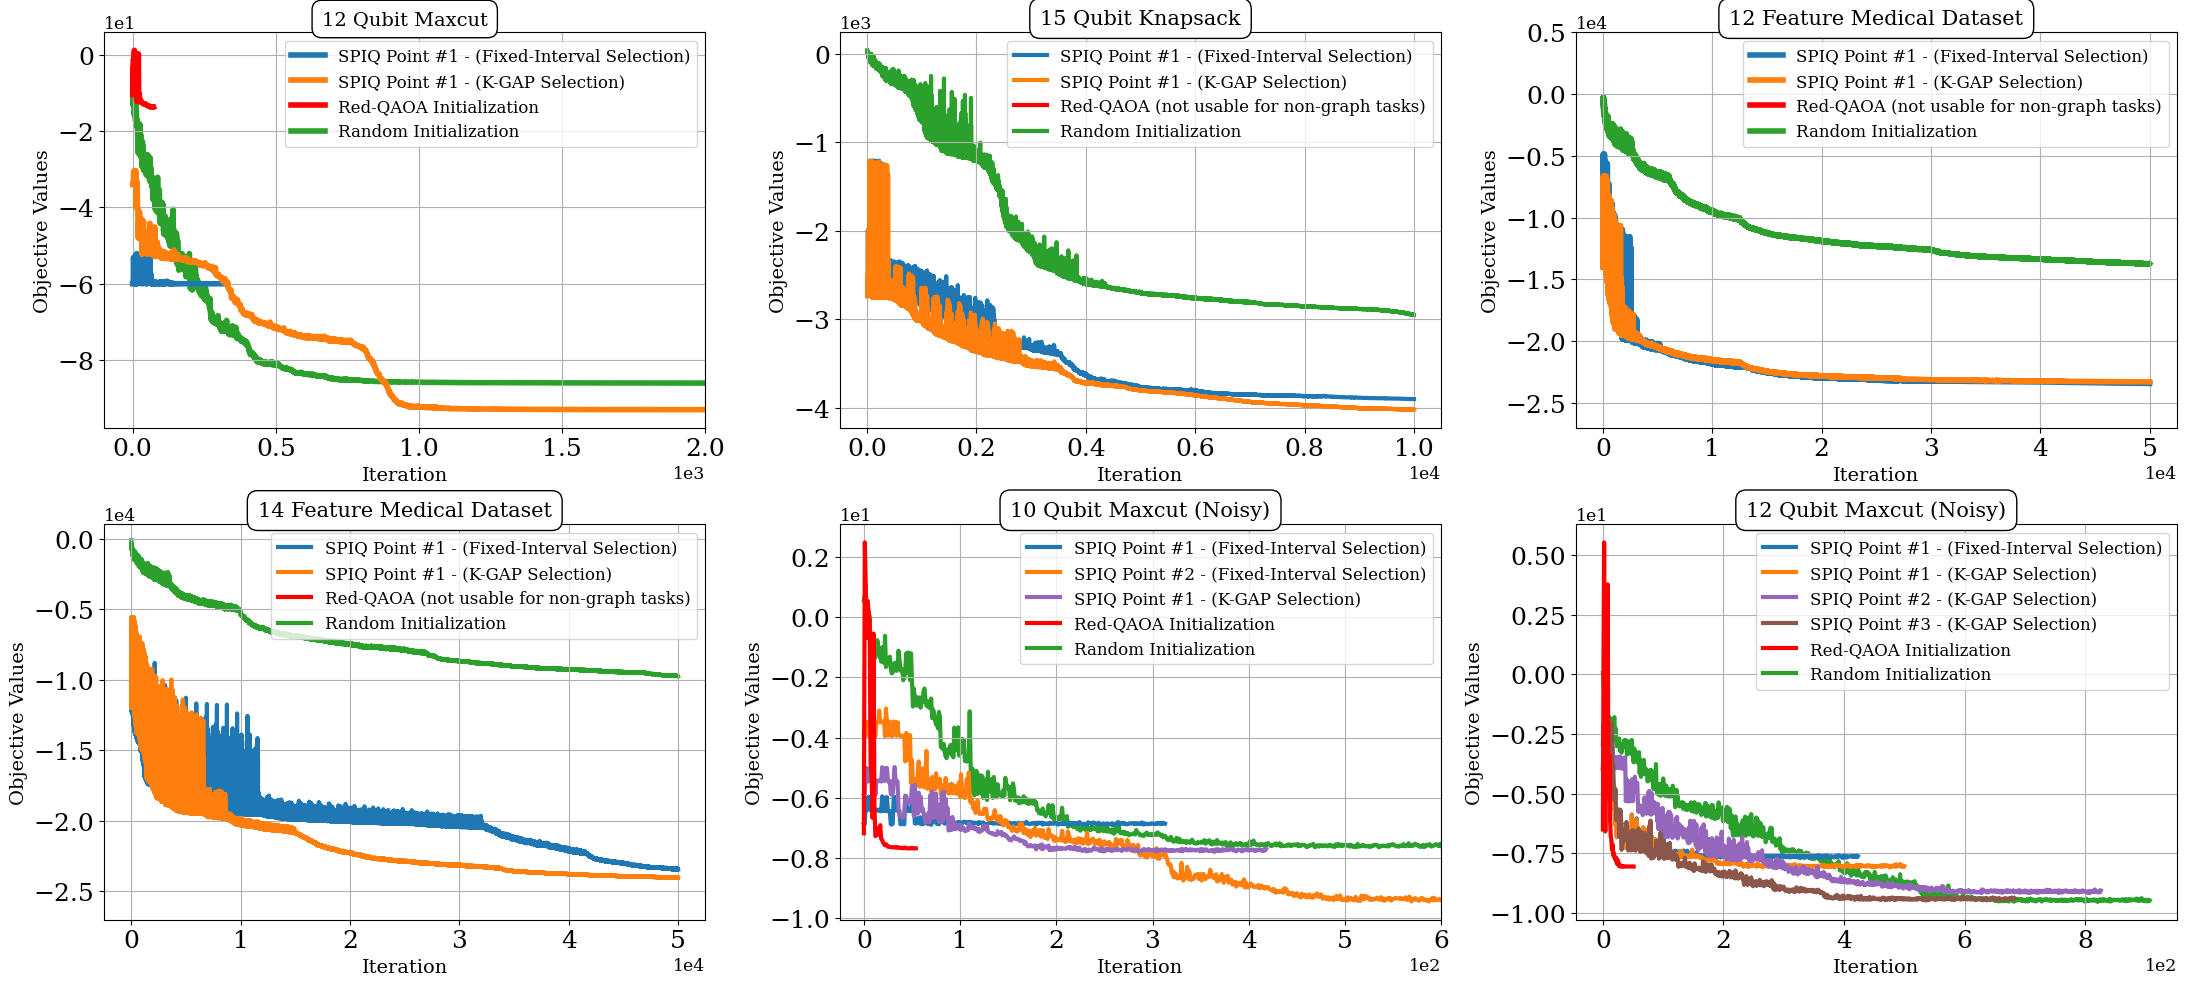

In [ ]:
# Create a new figure with subplots
fig, axs = plt.subplots(2, 3, figsize=(22,10))  # 2 rows, 3 columns
axs = axs.flatten()  # Flatten the 2D array of axes to 1D for easier indexing


# legend_locations = [
#     (0.7, 0.66),  # Custom location for subplot 1
#     (0.5, 0.5),   # Custom location for subplot 2
#     (0.8, 0.7),   # Custom location for subplot 3
#     (0.6, 0.6),   # Custom location for subplot 4
#     (0.5, 0.4),   # Custom location for subplot 5
#     (0.7, 0.5)    # Custom location for subplot 6
# ]

# # Apply custom legend locations
# for ax, loc in zip(axs, legend_locations):
#     ax.legend(loc='center', bbox_to_anchor=loc)

# Add the first plot to the first subplot

fig1_axes = fig1.get_axes()[0]  # Get the axes from fig1
for line in fig1_axes.get_lines():
    axs[0].plot(line.get_xdata(), line.get_ydata(), label=line.get_label(), linewidth=4 , color=line.get_color(),zorder=line.get_zorder())
    axs[0].set_xlim(-100, 2000)
axs[0].set_title('12 Qubit Maxcut', fontsize=14, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

# Add the second plot to the second subplot
fig2_axes = fig2.get_axes()[0]  # Get the axes from fig2
for line in fig2_axes.get_lines():
    axs[1].plot(line.get_xdata(), line.get_ydata(), label=line.get_label(), linewidth=3, color=line.get_color(),zorder=line.get_zorder())
axs[1].set_title('15 Qubit Knapsack', fontsize=15, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

# Add the third plot to the third subplot
fig3_axes = fig3.get_axes()[0]  # Get the axes from fig3
for line in fig3_axes.get_lines():
    axs[2].plot(line.get_xdata(), line.get_ydata(), label=line.get_label(), linewidth=4,color=line.get_color(),zorder=line.get_zorder())
    axs[2].set_ylim(-27000, 5000)
axs[2].set_title('12 Feature Medical Dataset', fontsize=15, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

# Add the fourth plot to the fourth subplot
fig4_axes = fig4.get_axes()[0]  # Get the axes from fig4
for line in fig4_axes.get_lines():
    axs[3].plot(line.get_xdata(), line.get_ydata(), label=line.get_label(), linewidth=3,color=line.get_color(),zorder=line.get_zorder())
    axs[3].set_ylim(-27000,1000)
    # plt.ylim(-27000,1000)
axs[3].set_title('14 Feature Medical Dataset', fontsize=15, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

# Add the fifth plot to the fourth subplot
fig5_axes = fig5.get_axes()[0]  # Get the axes from fig4
for line in fig5_axes.get_lines():
    axs[4].plot(line.get_xdata(), line.get_ydata(), label=line.get_label(), linewidth=3,color=line.get_color(),zorder=line.get_zorder())
    axs[4].set_xlim(-25, 600)
axs[4].set_title('10 Qubit Maxcut (Noisy)', fontsize=15, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

# Add the fifth plot to the fourth subplot
fig6_axes = fig6.get_axes()[0]  # Get the axes from fig4
for line in fig6_axes.get_lines():
    axs[5].plot(line.get_xdata(), line.get_ydata(), label=line.get_label(), linewidth=3,color=line.get_color(),zorder=line.get_zorder())
    # axs[5].set_xlim(-10, 200)
    # plt.xlim(-10,200)
axs[5].set_title('12 Qubit Maxcut (Noisy)', fontsize=15, bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))


# Customize the subplots
for ax in axs:
    ax.legend(loc='upper right',fontsize=12)
    ax.grid()
    ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
    ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
    ax.set_xlabel('Iteration', fontsize=14)
    ax.set_ylabel('Objective Values', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=18)

# Adjust layout and show the combined figure
plt.tight_layout()
# plt.savefig('../plots/multi-start_subplots.pdf', dpi=800, bbox_inches='tight')
plt.show()